# Model Selection and Regularization

**Data**: the `diabetes` dataset from the R package `lars`, using the expanded
design matrix `x2` (10 main effects + 9 squares + 45 pairwise interactions =
64 predictors). `export_diabetes.R` exports it, together with the exact
70/30 train/test split (`set.seed(123); sample(seq_len(nrow(diabetes)), 0.7*nrow(diabetes))`), to
`diabetes_train.csv` and `diabetes_test.csv` in this folder -- so this
notebook reads the *same* split the lecture slides use, rather than
re-splitting in Python.

### R → Python mapping

| R | Python |
|---|---|
| `lm()` | `statsmodels.api.OLS` |
| `ols_step_backward_p()` | `backward_elimination_p()` (written below) |
| `regsubsets()` | `best_subset()` (written below) |
| `glmnet(alpha=1)` | `lasso_path_glmnet()` (glmnet-scaled Lasso) |
| `glmnet(alpha=0)` | `ridge_path_glmnet()` (glmnet-scaled Ridge) |
| `caret::train(cv)` | `sklearn` `KFold` cross-validation |
| `MASS::stepAIC()` | `step_aic()` (written below) |

### glmnet vs. scikit-learn penalty scales

glmnet standardizes `X` internally and minimizes

$$\text{lasso}:\ \tfrac{1}{2N}\lVert y-X\beta\rVert^2+\lambda\lVert\beta\rVert_1
\qquad
\text{ridge}:\ \tfrac{1}{2N}\lVert y-X\beta\rVert^2+\tfrac{\lambda}{2}\lVert\beta\rVert^2$$

scikit-learn's `Lasso` minimizes $\tfrac{1}{2n}\text{RSS}+\alpha\lVert w\rVert_1$, so
$\alpha=\lambda$. scikit-learn's `Ridge` minimizes $\text{RSS}+\alpha\lVert w\rVert^2$, so
$\alpha = n\lambda$. Both are handled inside the path helpers below, which also
standardize `X` the way glmnet does and return coefficients on the original scale.



In [ ]:
import os
import time
import warnings
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import lasso_path
from sklearn.model_selection import KFold

# sklearn's coordinate-descent solver doesn't always converge to full
# precision at the extreme (large-lambda) end of the path grid used below;
# it doesn't materially change the coefficients (they're ~0 there anyway),
# so the warning is silenced for readability.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

%matplotlib inline


# Run this cell
def significance_stars(p):
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    elif p < 0.1:
        return '.'
    else:
        return ''

def print_summary_with_stars(model):
    summary = model.summary2()
    coef_table = summary.tables[1].copy()

    coef_table['Signif'] = coef_table['P>|t|'].apply(significance_stars)

    numeric_columns = coef_table.select_dtypes(include=['float64', 'int64']).columns
    coef_table[numeric_columns] = coef_table[numeric_columns].round(2)
    coef_str = coef_table.to_string(index=True)

    # Determine max width
    other_texts = [
        "Regression Results",
        "Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1",
        f"R-squared: {model.rsquared:.2f}",
        # f"Adjusted R-squared: {model.rsquared_adj:.2f}",
        f"No. Observations: {int(model.nobs)}",
    ]
    max_width = max(
        max(len(line) for line in coef_str.splitlines()),
        *(len(t) for t in other_texts)
    )

    def line(char="="):
        return char * max_width

    # Print nicely formatted summary
    print(line("="))
    print("Regression Results")
    print(line("="))

    print(f"R-squared: {model.rsquared:.2f}")
    # print(f"Adjusted R-squared: {model.rsquared_adj:.2f}")
    print(f"No. Observations: {int(model.nobs)}")

    print(line("="))
    print("Coefficients:")
    print(line("-"))
    print(coef_str)
    print(line("="))
    print("Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1")
    print(line("="))


## Settings

In [ ]:
HERE = os.getcwd()
TRAIN_DATA = os.path.join(HERE, "diabetes_train.csv")
TEST_DATA = os.path.join(HERE, "diabetes_test.csv")
FIGDIR = os.path.join(HERE, "figures")

SAVE_FIGS = True
SHOW_FIGS = True

# The two cross-validation loops over the stepwise penalty (end of the notebook)
# take a long time -- the R script says the same ("takes a while, so we won't
# do it in lecture"). Flip to True to actually run them.
RUN_STEPWISE_CV = False

# Chart colors: slots 1-3 of a colorblind-safe categorical palette.
C_TRAIN, C_TEST, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"
C_PATH = "#2a78d6"
INK, INK_MUTED = "#1a1a19", "#767570"

## Small helpers

In [ ]:
def rmse(y, pred):
    """Root mean squared error."""
    return float(np.sqrt(np.mean((np.asarray(y) - np.asarray(pred)) ** 2)))


def r2(y, pred, baseline):
    """1 - SSE/SST.  `baseline` is the mean predicted when nothing is known.

    In sample use baseline = mean(y_train); out of sample the R script also
    uses mean(y_train), which is what makes it an *out-of-sample* R^2 (OSR2).
    """
    y, pred = np.asarray(y), np.asarray(pred)
    return float(1 - np.sum((pred - y) ** 2) / np.sum((baseline - y) ** 2))


def fit_ols(X, y):
    """lm(y ~ ., data) -- X is a DataFrame of predictors, intercept added here."""
    return sm.OLS(np.asarray(y, float), sm.add_constant(X, has_constant="add")).fit()


def new_figure(xlabel, ylabel, figsize=(7.5, 5)):
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel(ylabel, fontsize=14)
    ax.tick_params(labelsize=12, colors=INK_MUTED, length=0)
    ax.grid(True, color="#e6e5e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ("top", "right", "left", "bottom"):
        ax.spines[side].set_visible(False)
    return fig, ax


def finish(fig, name):
    fig.tight_layout()
    if SAVE_FIGS:
        os.makedirs(FIGDIR, exist_ok=True)
        fig.savefig(os.path.join(FIGDIR, name + ".png"), dpi=150)
    if SHOW_FIGS:
        plt.show()
    else:
        plt.close(fig)

## Data importation

The training and test sets were produced once by `export_diabetes.R`,
using the same `diabetes` data (`lars` package, expanded design matrix
`x2`) and the same 70/30 split as the following R code:

```r
set.seed(123)
train.obs <- sort(sample(seq_len(nrow(diabetes)), 0.7*nrow(diabetes)))
train <- diabetes[train.obs,]
test <- diabetes[-train.obs,]
```

so they are read here directly, rather than re-split in Python.

In [ ]:
train = pd.read_csv(TRAIN_DATA)
test = pd.read_csv(TEST_DATA)
train.head(10)

,y,age,sex,bmi,map,tc,ldl,hdl,tch,ltg,...,ldl:hdl,ldl:tch,ldl:ltg,ldl:glu,hdl:tch,hdl:ltg,hdl:glu,tch:ltg,tch:glu,ltg:glu
0,75,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068330,...,-0.021256,-0.011564,0.012973,0.023783,-0.023815,-0.094506,-0.140378,0.025298,0.053034,0.104013
1,206,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022692,...,-0.009878,-0.009984,-0.003373,-0.019109,0.008159,0.001898,0.021514,-0.012045,-0.024872,-0.025042
2,135,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031991,...,0.012376,-0.024091,-0.026846,-0.029687,0.030984,0.014489,0.005386,-0.025575,-0.016180,0.008735
3,138,-0.045472,0.050680,-0.047163,-0.015999,-0.040096,-0.024800,0.000779,-0.039493,-0.062913,...,0.009208,-0.008066,0.018496,0.006298,0.030803,0.019267,0.013254,0.021137,0.011224,0.026986
4,310,-0.070900,-0.044642,0.039062,-0.033214,-0.012577,-0.034508,-0.024993,-0.002592,0.067736,...,0.028304,-0.022051,-0.067329,-0.004105,0.032597,-0.017875,0.021517,-0.030603,-0.017869,-0.038958
5,101,-0.096328,-0.044642,-0.083808,0.008101,-0.103389,-0.090561,-0.013948,-0.076395,-0.062913,...,0.036981,0.085251,0.109597,0.052328,0.051393,0.040200,0.024659,0.066290,0.032830,0.021822
6,179,0.016281,-0.044642,-0.028840,-0.009113,-0.004321,-0.009769,0.044958,-0.039493,-0.030751,...,0.000114,-0.017394,-0.009245,-0.005194,-0.001968,-0.010863,-0.029045,-0.003567,0.014440,0.005065
7,185,0.005383,0.050680,-0.001895,0.008101,-0.004321,-0.015719,-0.002903,-0.002592,0.038393,...,0.010614,-0.022816,-0.029149,-0.009544,0.031522,0.017856,0.014808,-0.029123,-0.017869,-0.031106
8,171,-0.052738,0.050680,-0.018062,0.080401,0.089244,0.107662,-0.039719,0.108111,0.036056,...,-0.082985,0.159433,0.069617,-0.112178,-0.049270,-0.011983,0.051890,0.048626,-0.108887,-0.051197
9,168,-0.027310,-0.044642,-0.018062,-0.040099,-0.002945,-0.011335,0.037595,-0.039493,-0.008944,...,0.000397,-0.016422,-0.013628,-0.000748,0.003494,0.012777,-0.032513,-0.020317,0.024089,-0.011098


In [ ]:
test.head(5)

,y,age,sex,bmi,map,tc,ldl,hdl,tch,ltg,...,ldl:hdl,ldl:tch,ldl:ltg,ldl:glu,hdl:tch,hdl:ltg,hdl:glu,tch:ltg,tch:glu,ltg:glu
0,151,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019908,...,0.042355,-0.022038,-0.031125,-0.000922,0.033494,0.000852,0.031150,-0.028191,-0.017658,-0.027794
1,141,0.085299,0.050680,0.044451,-0.005671,-0.045599,-0.034194,-0.032356,-0.002592,0.002864,...,0.033587,-0.022063,-0.018016,0.004913,0.032956,0.018281,0.032795,-0.027332,-0.017236,-0.022304
2,97,-0.092695,-0.044642,-0.040696,-0.019442,-0.068991,-0.079288,0.041277,-0.076395,-0.041180,...,-0.061252,0.071719,0.056037,0.149663,-0.027844,-0.018031,-0.075513,0.033999,0.126147,0.057789
3,63,0.063504,0.050680,-0.001895,0.066630,0.090620,0.108914,0.022869,0.017703,-0.035817,...,0.063567,0.006841,-0.101758,-0.006939,0.038984,0.001868,0.015502,-0.039520,-0.017491,-0.023007
4,110,0.041708,0.050680,0.061696,-0.040099,-0.013953,0.006202,-0.028674,-0.002592,-0.014956,...,0.005775,-0.023709,-0.017902,-0.012585,0.032777,0.030064,0.006608,-0.026433,-0.019136,-0.024196


In [ ]:
PREDICTORS = [c for c in train.columns if c != "y"]
X_train, y_train = train[PREDICTORS], train["y"].to_numpy(float)
X_test, y_test = test[PREDICTORS], test["y"].to_numpy(float)

# Number of predictors
k = len(PREDICTORS)
print(f"n_train = {len(train)}, n_test = {len(test)}, k = {k}")

n_train = 309, n_test = 133, k = 64


## Initial models

### Full model, with all variables

In [ ]:
t0 = time.time()
full = fit_ols(X_train, y_train)
print(f"full model fit time: {time.time() - t0:.4f}s")
# full.summary()

full model fit time: 0.0481s


In [ ]:
print_summary_with_stars(full)

Regression Results
R-squared: 0.63
No. Observations: 309
Coefficients:
---------------------------------------------------------------------
           Coef.  Std.Err.      t  P>|t|     [0.025     0.975] Signif
const     154.25      3.19  48.32   0.00     147.96     160.53    ***
age       138.81     83.03   1.67   0.10     -24.74     302.36      .
sex      -196.66     85.21  -2.31   0.02    -364.51     -28.81      *
bmi       560.60    109.43   5.12   0.00     345.06     776.13    ***
map       290.25     93.48   3.10   0.00     106.12     474.37     **
tc       -989.91  79936.43  -0.01   0.99 -158443.41  156463.58       
ldl       867.34  70258.28   0.01   0.99 -137522.78  139257.45       
hdl        39.14  29883.58   0.00   1.00  -58823.56   58901.84       
tch      -227.84    341.15  -0.67   0.50    -899.81     444.13       
ltg       953.54  26282.71   0.04   0.97  -50816.41   52723.49       
glu         6.75     90.36   0.07   0.94    -171.24     184.74       
age^2      57.78   

In [ ]:
r2(y_test, full.predict(sm.add_constant(X_test, has_constant="add")),
   y_train.mean())

0.3398965643753321

In [ ]:
prediction_full_train = full.predict(sm.add_constant(X_train, has_constant="add"))
R2_full = full.rsquared
rmse_full_train = rmse(y_train, prediction_full_train)

prediction_full = full.predict(sm.add_constant(X_test, has_constant="add"))
OSR2_full = r2(y_test, prediction_full, y_train.mean())
RMSE_full = rmse(y_test, prediction_full)

print(f"FULL   R2 = {R2_full:.4f}  RMSE(train) = {rmse_full_train:.2f}"
      f"  OSR2 = {OSR2_full:.4f}  RMSE(test) = {RMSE_full:.2f}")

FULL   R2 = 0.6308  RMSE(train) = 47.37  OSR2 = 0.3399  RMSE(test) = 60.74


In [ ]:
import statsmodels.formula.api as smf

model_sig = smf.ols(formula="y ~ sex + bmi + map + age:sex", data=train).fit()


In [ ]:
r2(y_test, model_sig.predict(sm.add_constant(X_test, has_constant="add")),
   y_train.mean())

0.3114543899350677

In [ ]:
print_summary_with_stars(model_sig)

Regression Results
R-squared: 0.45
No. Observations: 309
Coefficients:
-------------------------------------------------------------------
             Coef.  Std.Err.      t  P>|t|   [0.025   0.975] Signif
Intercept   150.99      3.38  44.65   0.00   144.34   157.65    ***
sex         -40.02     72.41  -0.55   0.58  -182.50   102.47       
bmi         856.93     74.82  11.45   0.00   709.71  1004.16    ***
map         391.68     79.25   4.94   0.00   235.73   547.63    ***
age:sex    3949.77   1496.48   2.64   0.01  1005.00  6894.55     **
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


In [ ]:
model_chol = smf.ols(formula="y ~ tc + ldl + hdl + tch + ltg + glu", data=train).fit()
print_summary_with_stars(model_chol)

Regression Results
R-squared: 0.37
No. Observations: 309
Coefficients:
------------------------------------------------------------------
            Coef.  Std.Err.      t  P>|t|   [0.025   0.975] Signif
Intercept  152.97      3.59  42.63   0.00   145.91   160.03    ***
tc        -491.12    566.42  -0.87   0.39 -1605.75   623.50       
ldl        371.52    456.99   0.81   0.42  -527.78  1270.82       
hdl       -184.79    292.68  -0.63   0.53  -760.74   391.16       
tch        -39.42    231.81  -0.17   0.87  -495.58   416.74       
ltg        923.14    234.29   3.94   0.00   462.08  1384.19    ***
glu        161.50     89.19   1.81   0.07   -14.01   337.00      .
Significance codes: '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1


In [ ]:
r2(y_test, model_chol.predict(sm.add_constant(X_test, has_constant="add")),
   y_train.mean())

0.388023944405952

### One step at a time, remove insignificant variables

R: `ols_step_backward_p(full, prem = 0.05)`

In [ ]:
def backward_elimination_p(X, y, prem=0.05, progress=False):
    """Drop the least significant predictor until every p-value <= prem."""
    kept = list(X.columns)
    while kept:
        model = fit_ols(X[kept], y)
        pvals = model.pvalues.drop("const")
        worst = pvals.idxmax()
        if pvals[worst] <= prem:
            return model, kept
        if progress:
            print(f"  dropping {worst:<12} p = {pvals[worst]:.4f}")
        kept.remove(worst)
    return fit_ols(X[[]], y), []

lm_modr, kept_backward_p = backward_elimination_p(X_train, y_train, prem=0.05,
                                                  progress=True)
# lm_modr.summary()


  dropping hdl          p = 0.9990
  dropping sex:glu      p = 0.9975
  dropping bmi:ldl      p = 0.9910
  dropping map^2        p = 0.9747
  dropping sex:ltg      p = 0.9705
  dropping bmi:hdl      p = 0.9472
  dropping glu          p = 0.9341
  dropping tch:ltg      p = 0.8780
  dropping age:ldl      p = 0.8372
  dropping age:map      p = 0.8096
  dropping bmi:glu      p = 0.7845
  dropping sex:map      p = 0.6990
  dropping map:ldl      p = 0.7390
  dropping map:ltg      p = 0.7636
  dropping age:ltg      p = 0.6126
  dropping glu^2        p = 0.5398
  dropping age^2        p = 0.5292
  dropping map:hdl      p = 0.5232
  dropping map:tch      p = 0.8439
  dropping age:tc       p = 0.5702
  dropping age:tch      p = 0.7812
  dropping bmi:tc       p = 0.5300
  dropping age:hdl      p = 0.4977
  dropping bmi:map      p = 0.5235
  dropping tch          p = 0.4726
  dropping ldl:glu      p = 0.4533
  dropping ltg:glu      p = 0.6694
  dropping tc:glu       p = 0.6848
  dropping map:glu  

In [ ]:
r2(y_test, lm_modr.predict(sm.add_constant(X_test[kept_backward_p], has_constant="add")),
   y_train.mean())

0.3582379167349917

In [ ]:
print_summary_with_stars(lm_modr)

Regression Results
R-squared: 0.59
No. Observations: 309
Coefficients:
-----------------------------------------------------------------
           Coef.  Std.Err.      t  P>|t|   [0.025   0.975] Signif
const     153.99      2.97  51.91   0.00   148.15   159.82    ***
bmi       700.84     75.21   9.32   0.00   552.82   848.86    ***
map       256.57     70.00   3.67   0.00   118.80   394.34    ***
tc       -183.19     76.42  -2.40   0.02  -333.59   -32.79      *
ltg       715.10    100.78   7.10   0.00   516.77   913.44    ***
tch^2     285.66     98.73   2.89   0.00    91.34   479.97     **
ltg^2     623.49    204.98   3.04   0.00   220.06  1026.91     **
age:sex   206.58     65.01   3.18   0.00    78.64   334.52     **
age:glu   174.21     68.66   2.54   0.01    39.09   309.33      *
sex:bmi   176.54     70.62   2.50   0.01    37.54   315.53      *
sex:tch  -200.66     78.39  -2.56   0.01  -354.94   -46.37      *
map:tc    184.11     69.22   2.66   0.01    47.87   320.34     **
tc:lt

In [ ]:
print("retained:", kept_backward_p)

retained: ['bmi', 'map', 'tc', 'ltg', 'tch^2', 'ltg^2', 'age:sex', 'age:glu', 'sex:bmi', 'sex:tch', 'map:tc', 'tc:ltg', 'ldl:ltg', 'hdl:ltg']


## Subset selection

### Manual predict function

(Not needed in Python -- `statsmodels` predicts directly on a DataFrame of the selected columns; see `best_subset` below.)

In [ ]:
def rss_of(Xmat, y):
    """Residual sum of squares of the OLS fit of y on Xmat (intercept added)."""
    A = np.column_stack([np.ones(len(Xmat)), Xmat])
    beta, *_ = np.linalg.lstsq(A, y, rcond=None)
    resid = y - A @ beta
    return float(resid @ resid), beta


def best_subset(X, y, nvmax):
    """Exhaustive best subset selection -- R's regsubsets(really.big = TRUE).

    Returns {size: (columns, RSS)} for size = 1..nvmax.
    """
    cols = list(X.columns)
    Xv = X.to_numpy(float)
    idx = {c: j for j, c in enumerate(cols)}
    out = {}
    for size in range(1, nvmax + 1):
        best = (np.inf, None)
        for combo in combinations(cols, size):
            r, _ = rss_of(Xv[:, [idx[c] for c in combo]], y)
            if r < best[0]:
                best = (r, combo)
        out[size] = (list(best[1]), best[0])
    return out

### Comparison of runtimes for best subset selection

Exhaustive search over all 64 predictors is combinatorially hopeless in pure
Python (C(64, 9) ≈ 2.7e10 subsets), so the runtime demo uses the 10 main
effects only. That is the point of the exercise: watch the time explode.

In [ ]:
#MAIN_EFFECTS = ["age", "sex", "bmi", "map", "tc", "ldl", "hdl", "tch", "ltg", "glu"]
MAIN_EFFECTS = list(X_train.columns)
CPU_best_subset = np.zeros(9)
for i in range(1, 10):
    start_time = time.time()
    subsets = best_subset(X_train[MAIN_EFFECTS], y_train, nvmax=i)
    CPU_best_subset[i - 1] = time.time() - start_time
    print(f"nvmax = {i}: {CPU_best_subset[i - 1]:7.3f}s   best = {subsets[i][0]}")

nvmax = 1:   0.033s   best = ['bmi']
nvmax = 2:   0.462s   best = ['bmi', 'ltg']
nvmax = 3:   4.115s   best = ['bmi', 'map', 'ltg']
nvmax = 4:  52.065s   best = ['bmi', 'map', 'ltg', 'age:sex']
nvmax = 5: 676.080s   best = ['bmi', 'map', 'ltg', 'age:sex', 'age:glu']


KeyboardInterrupt: 

## Lasso

### Preparation of the train and test matrices

In [ ]:
x_train = X_train.to_numpy(float)
x_test = X_test.to_numpy(float)


def _standardize(X):
    """glmnet's internal standardization: center, scale by population sd."""
    mu = X.mean(axis=0)
    sd = X.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0
    return (X - mu) / sd, mu, sd


def lasso_path_glmnet(X, y, lambdas):
    """glmnet(alpha = 1) over a lambda grid; coefficients on the original scale.

    Returns (intercepts, betas) with betas shaped (n_lambda, n_features).
    """
    Xs, mu, sd = _standardize(X)
    ybar = y.mean()
    # sklearn's lasso_path wants alphas descending; alpha == lambda here.
    order = np.argsort(-np.asarray(lambdas))
    _, coefs, _ = lasso_path(Xs, y - ybar, alphas=np.asarray(lambdas)[order])
    betas = np.empty((len(lambdas), X.shape[1]))
    betas[order] = coefs.T
    betas /= sd  # back to the original scale
    intercepts = ybar - betas @ mu
    return intercepts, betas


def ridge_path_glmnet(X, y, lambdas):
    """glmnet(alpha = 0) over a lambda grid, solved in closed form via SVD."""
    Xs, mu, sd = _standardize(X)
    ybar = y.mean()
    n = X.shape[0]
    U, s, Vt = np.linalg.svd(Xs, full_matrices=False)
    Uty = U.T @ (y - ybar)
    # sklearn/closed-form ridge penalty alpha = n * lambda (see intro)
    alphas = n * np.asarray(lambdas, float)
    shrink = s[None, :] / (s[None, :] ** 2 + alphas[:, None])
    betas = (shrink * Uty[None, :]) @ Vt
    betas /= sd
    intercepts = ybar - betas @ mu
    return intercepts, betas


def path_predict(X, intercepts, betas):
    """Predictions for every lambda: shape (n_obs, n_lambda)."""
    return np.asarray(X, float) @ betas.T + intercepts[None, :]

### Run Lasso in the train set

In [ ]:
lambdas_lasso = np.exp(np.arange(5, -5.001, -0.01))
lasso_int, lasso_beta = lasso_path_glmnet(x_train, y_train, lambdas_lasso)

### Plot Lasso path

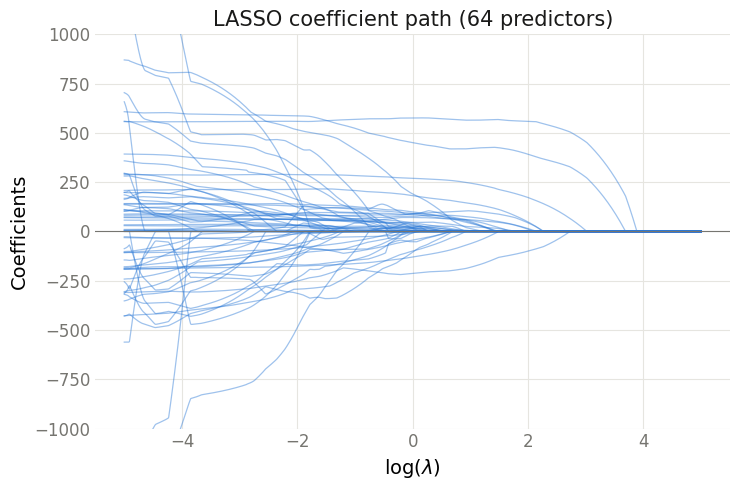

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "Coefficients")
ax.plot(np.log(lambdas_lasso), lasso_beta, color=C_PATH, linewidth=0.9, alpha=0.45)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylim(-1000, 1000)
ax.set_title("LASSO coefficient path (64 predictors)", fontsize=15, color=INK)
finish(fig, "lasso_path")

### Prediction on the train and test sets, and performance assessment

In [ ]:
lasso_pred_train = path_predict(x_train, lasso_int, lasso_beta)
lasso_pred_test = path_predict(x_test, lasso_int, lasso_beta)

lasso_rmse_train = np.sqrt(np.mean((y_train[:, None] - lasso_pred_train) ** 2, axis=0))
lasso_rmse_test = np.sqrt(np.mean((y_test[:, None] - lasso_pred_test) ** 2, axis=0))
lasso_R2_train = np.array([r2(y_train, p, y_train.mean()) for p in lasso_pred_train.T])
lasso_R2_test = np.array([r2(y_test, p, y_train.mean()) for p in lasso_pred_test.T])

rmse_lasso = pd.DataFrame({"lambda": lambdas_lasso,
                           "train": lasso_rmse_train, "test": lasso_rmse_test})
R2_lasso = pd.DataFrame({"lambda": lambdas_lasso,
                         "R2": lasso_R2_train, "OSR2": lasso_R2_test})

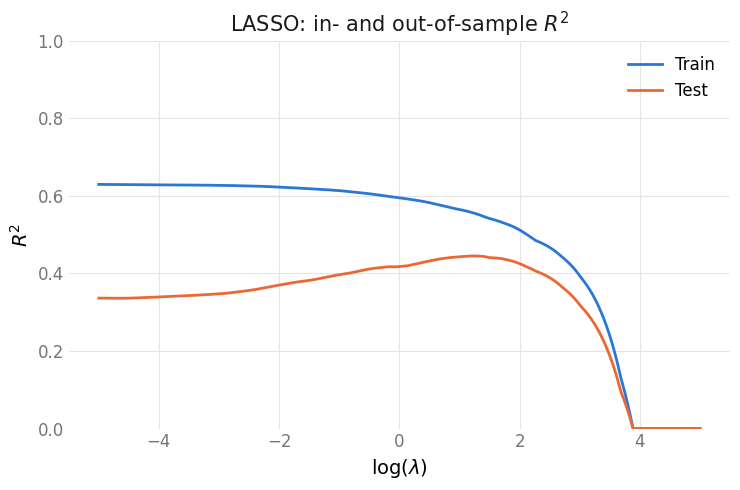

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "$R^2$")
ax.plot(np.log(lambdas_lasso), lasso_R2_train, color=C_TRAIN, lw=2, label="Train")
ax.plot(np.log(lambdas_lasso), lasso_R2_test, color=C_TEST, lw=2, label="Test")
ax.set_ylim(0, 1)
ax.legend(fontsize=12, frameon=False)
ax.set_title("LASSO: in- and out-of-sample $R^2$", fontsize=15, color=INK)
finish(fig, "lasso_r2")

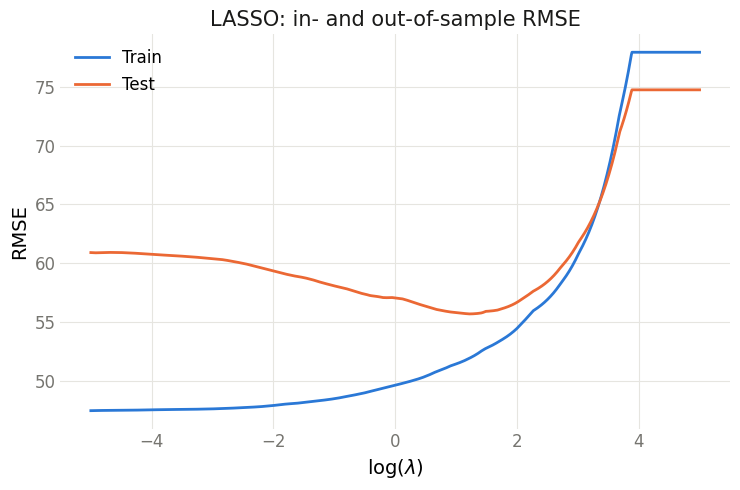

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "RMSE")
ax.plot(np.log(lambdas_lasso), lasso_rmse_train, color=C_TRAIN, lw=2, label="Train")
ax.plot(np.log(lambdas_lasso), lasso_rmse_test, color=C_TEST, lw=2, label="Test")
ax.legend(fontsize=12, frameon=False)
ax.set_title("LASSO: in- and out-of-sample RMSE", fontsize=15, color=INK)
finish(fig, "lasso_rmse")

lasso_nonzero = pd.DataFrame({"lambda": lambdas_lasso,
                              "nonzero": (lasso_beta != 0).sum(axis=1)})

### Cross-validation

R uses `caret::train(method = "glmnet", trControl = cv, number = 10)`.
caret reports `Rsquared` as the squared correlation; we use $1-\text{SSE/SST}$, which
peaks at essentially the same lambda.

In [ ]:
from sklearn.linear_model import LassoCV
from sklearn.model_selection import KFold

# Define a reasonable range for alpha (lambda in glmnet) for LassoCV
# Reusing the lambdas_lasso_cv array which was already defined and covers a good range.
alphas_range = lambdas_lasso_cv

# Instantiate KFold for consistency with previous CV setup (same splits and random_state)
kf = KFold(n_splits=10, shuffle=True, random_state=144)

# Instantiate LassoCV
# Set random_state for reproducibility of the solver, and verbose=False to suppress detailed output
lasso_cv_sk = LassoCV(alphas=alphas_range, cv=kf, random_state=144, verbose=False)

# Fit LassoCV model to the training data
lasso_cv_sk.fit(x_train, y_train)

# Extract results
alphas_evaluated = lasso_cv_sk.alphas_
# mse_path_ contains the mean squared errors for each fold and each alpha
# It has shape (n_folds, n_alphas)
mse_path = lasso_cv_sk.mse_path_

# Calculate OSR2 for each alpha for plotting
# Need to calculate SST for each validation fold using the global y_train.mean() as baseline
cv_r2_scores = np.empty_like(mse_path)

# Iterate through the KFold splits to get the validation sets for SST calculation
for f, (tr, va) in enumerate(kf.split(x_train)):
    y_val_fold = y_train[va]
    # Calculate SST for this validation fold relative to the overall training mean
    # This matches the definition of OSR2 used in the 'r2' function.
    sst_fold = ((y_val_fold - y_train.mean()) ** 2).sum()

    # Calculate SSE for each alpha in this fold
    # mse_path[f, :] are the mean squared errors PER SAMPLE for this fold and all alphas
    sse_fold_per_alpha = mse_path[f, :] * len(y_val_fold)

    # Calculate R2 for each alpha in this fold
    cv_r2_scores[f, :] = 1 - sse_fold_per_alpha / sst_fold

# Average R2 scores across folds for each alpha
mean_cv_r2_sklearn = np.mean(cv_r2_scores, axis=0)

# Plot out of sample R2 against log(alpha)
fig, ax = new_figure(r"log($\alpha$)", "Cross-Validation $R^2$ (LassoCV)")
ax.plot(np.log(alphas_evaluated), mean_cv_r2_sklearn, color=C_TRAIN, lw=2)
ax.axvline(np.log(lasso_cv_sk.alpha_), color=INK_MUTED, linestyle='--', label=f'Best alpha: {lasso_cv_sk.alpha_:.4f}')
ax.set_title("LassoCV: 10-fold cross-validation R^2", fontsize=15, color=INK)
ax.legend(fontsize=12, frameon=False)
finish(fig, "lasso_cv_sklearn_r2")

# Print the best alpha found by LassoCV and the corresponding R2
print(f"LassoCV best alpha: {lasso_cv_sk.alpha_:.4f}")
print(f"Max cross-validation R^2 with LassoCV: {np.max(mean_cv_r2_sklearn):.4f}")

In [ ]:
def cv_r2(path_fn, X, y, lambdas, n_splits=10, seed=144):
    """10-fold CV R^2 for every lambda on the grid."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    scores = np.zeros((n_splits, len(lambdas)))
    for f, (tr, va) in enumerate(kf.split(X)):
        ints, betas = path_fn(X[tr], y[tr], lambdas)
        pred = path_predict(X[va], ints, betas)
        sse = ((y[va][:, None] - pred) ** 2).sum(axis=0)
        sst = ((y[va] - y[tr].mean()) ** 2).sum()
        scores[f] = 1 - sse / sst
    return scores.mean(axis=0)


lambdas_lasso_cv = np.exp(np.arange(3.5, -5.001, -0.01))
t0 = time.time()
cv_lasso = pd.DataFrame({
    "lambda": lambdas_lasso_cv,
    "Rsquared": cv_r2(lasso_path_glmnet, x_train, y_train, lambdas_lasso_cv),
})
print(f"lasso CV time: {time.time() - t0:.2f}s")

lasso CV time: 8.92s


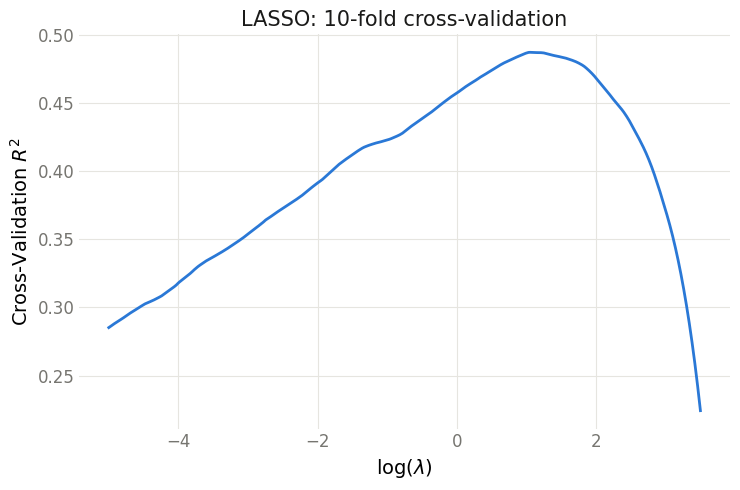

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "Cross-Validation $R^2$")
ax.plot(np.log(cv_lasso["lambda"]), cv_lasso["Rsquared"], color=C_TRAIN, lw=2)
ax.set_title("LASSO: 10-fold cross-validation", fontsize=15, color=INK)
finish(fig, "lasso_cv")

### Best lambda

In [ ]:
lasso_lambda_cv = float(cv_lasso.loc[cv_lasso["Rsquared"].idxmax(), "lambda"])
print(f"lasso best lambda = {lasso_lambda_cv:.4f}")

lasso best lambda = 2.9447


### In sample and out of sample performance

In [ ]:
li, lb = lasso_path_glmnet(x_train, y_train, [lasso_lambda_cv])
pred_train_final = path_predict(x_train, li, lb)[:, 0]
pred_test_final = path_predict(x_test, li, lb)[:, 0]
R2_lasso_final = r2(y_train, pred_train_final, y_train.mean())
rmse_lasso_final_train = rmse(y_train, pred_train_final)
OSR2_lasso_final = r2(y_test, pred_test_final, y_train.mean())
rmse_lasso_final = rmse(y_test, pred_test_final)
print(f"LASSO  R2 = {R2_lasso_final:.4f}  RMSE(train) = {rmse_lasso_final_train:.2f}"
      f"  OSR2 = {OSR2_lasso_final:.4f}  RMSE(test) = {rmse_lasso_final:.2f}"
      f"  nonzero = {(lb[0] != 0).sum()}")

LASSO  R2 = 0.5622  RMSE(train) = 51.58  OSR2 = 0.4439  RMSE(test) = 55.75  nonzero = 16


## Ridge Regression

### Run Ridge Regression in the train set

In [ ]:
lambdas_ridge = np.exp(np.arange(10, -5.001, -0.01))
ridge_int, ridge_beta = ridge_path_glmnet(x_train, y_train, lambdas_ridge)

### Plot ridge path

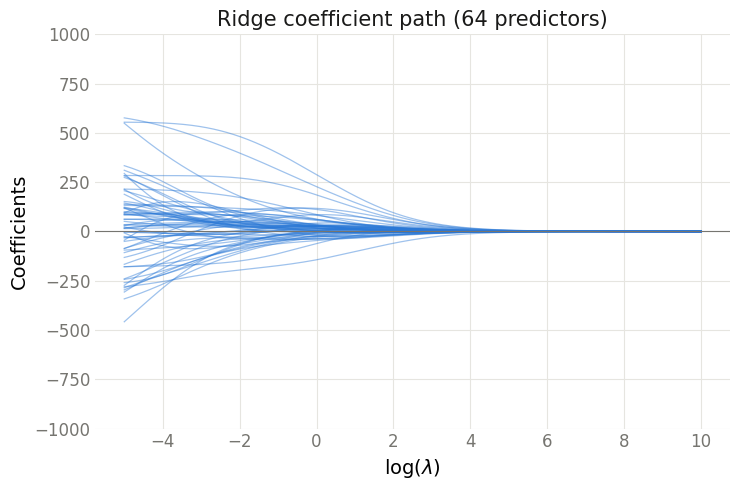

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "Coefficients")
ax.plot(np.log(lambdas_ridge), ridge_beta, color=C_PATH, linewidth=0.9, alpha=0.45)
ax.axhline(0, color=INK_MUTED, linewidth=0.8)
ax.set_ylim(-1000, 1000)
ax.set_title("Ridge coefficient path (64 predictors)", fontsize=15, color=INK)
finish(fig, "ridge_path")

### Prediction on the train and test sets, and performance assessment

In [ ]:
ridge_pred_train = path_predict(x_train, ridge_int, ridge_beta)
ridge_pred_test = path_predict(x_test, ridge_int, ridge_beta)

ridge_rmse_train = np.sqrt(np.mean((y_train[:, None] - ridge_pred_train) ** 2, axis=0))
ridge_rmse_test = np.sqrt(np.mean((y_test[:, None] - ridge_pred_test) ** 2, axis=0))
ridge_R2_train = np.array([r2(y_train, p, y_train.mean()) for p in ridge_pred_train.T])
ridge_R2_test = np.array([r2(y_test, p, y_train.mean()) for p in ridge_pred_test.T])

rmse_ridge = pd.DataFrame({"lambda": lambdas_ridge,
                           "train": ridge_rmse_train, "test": ridge_rmse_test})
R2_ridge = pd.DataFrame({"lambda": lambdas_ridge,
                         "R2": ridge_R2_train, "OSR2": ridge_R2_test})

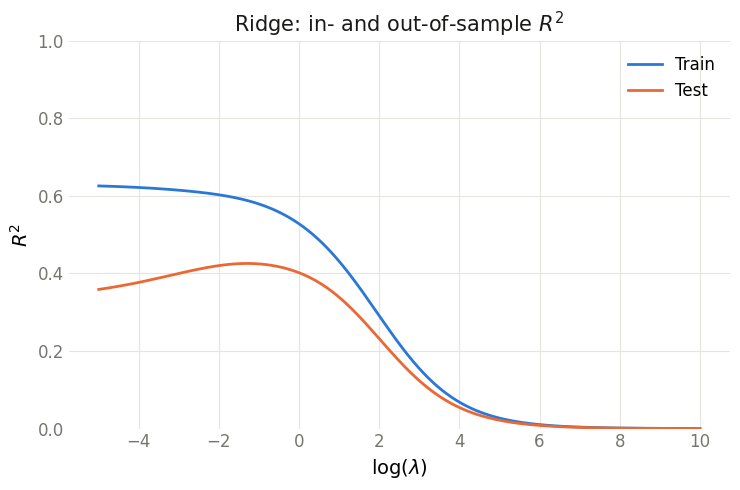

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "$R^2$")
ax.plot(np.log(lambdas_ridge), ridge_R2_train, color=C_TRAIN, lw=2, label="Train")
ax.plot(np.log(lambdas_ridge), ridge_R2_test, color=C_TEST, lw=2, label="Test")
ax.set_ylim(0, 1)
ax.legend(fontsize=12, frameon=False)
ax.set_title("Ridge: in- and out-of-sample $R^2$", fontsize=15, color=INK)
finish(fig, "ridge_r2")

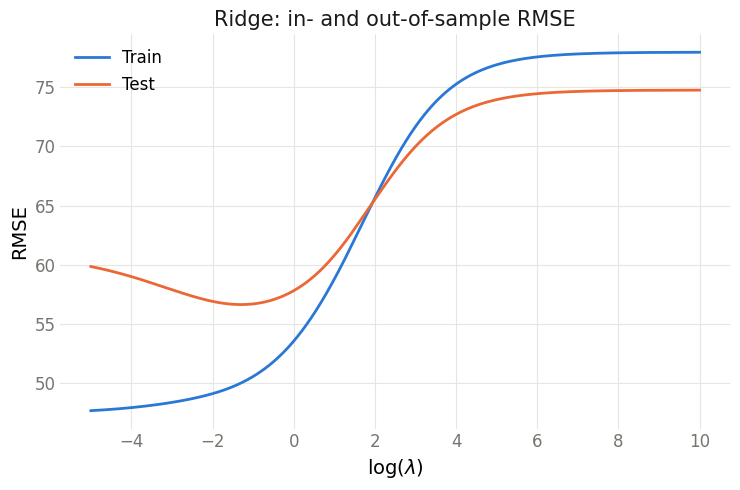

In [ ]:
fig, ax = new_figure(r"log($\lambda$)", "RMSE")
ax.plot(np.log(lambdas_ridge), ridge_rmse_train, color=C_TRAIN, lw=2, label="Train")
ax.plot(np.log(lambdas_ridge), ridge_rmse_test, color=C_TEST, lw=2, label="Test")
ax.legend(fontsize=12, frameon=False)
ax.set_title("Ridge: in- and out-of-sample RMSE", fontsize=15, color=INK)
finish(fig, "ridge_rmse")

ridge_nonzero = pd.DataFrame({
    "lambda": lambdas_ridge,
    "nonzero": (np.abs(ridge_beta) > 1e-5).sum(axis=1),
})

### Number of non-zero coefficients: ridge vs. lasso

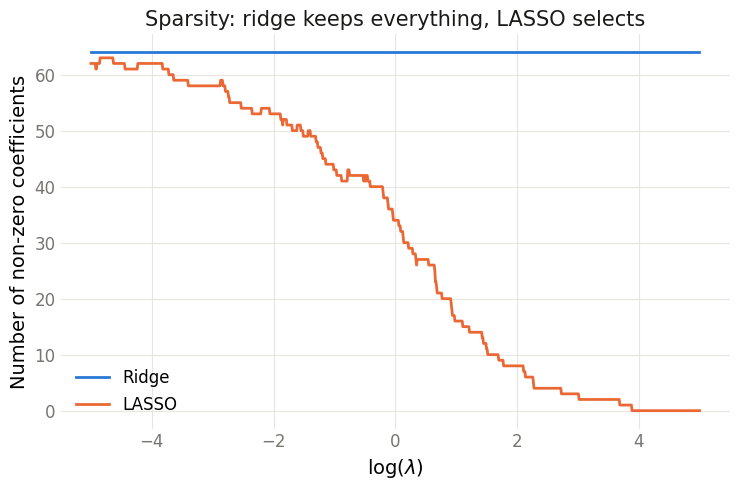

In [ ]:
mask = np.log(ridge_nonzero["lambda"]) <= 5
fig, ax = new_figure(r"log($\lambda$)", "Number of non-zero coefficients")
ax.plot(np.log(ridge_nonzero.loc[mask, "lambda"]), ridge_nonzero.loc[mask, "nonzero"],
        color=C_TRAIN, lw=2, label="Ridge")
ax.plot(np.log(lasso_nonzero["lambda"]), lasso_nonzero["nonzero"],
        color=C_TEST, lw=2, label="LASSO")
ax.legend(fontsize=12, frameon=False)
ax.set_title("Sparsity: ridge keeps everything, LASSO selects", fontsize=15, color=INK)
finish(fig, "nonzero_ridge_vs_lasso")

### Cross-validation

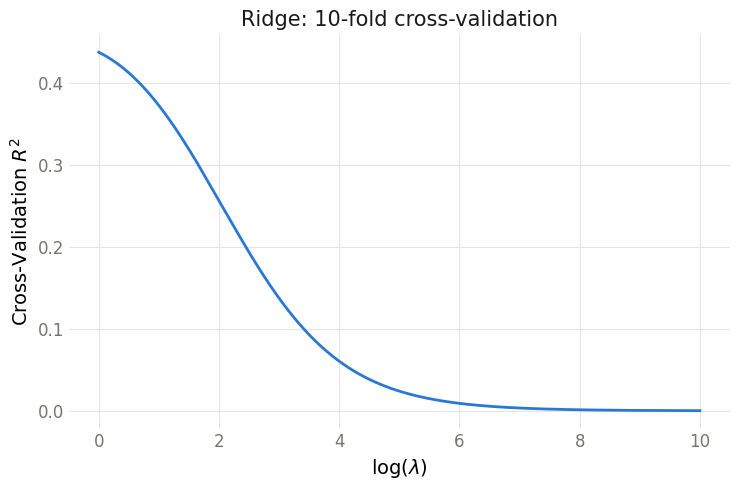

In [ ]:
cv_ridge = pd.DataFrame({
    "lambda": lambdas_ridge,
    "Rsquared": cv_r2(ridge_path_glmnet, x_train, y_train, lambdas_ridge),
})

sel = np.log(cv_ridge["lambda"]) >= 0
fig, ax = new_figure(r"log($\lambda$)", "Cross-Validation $R^2$")
ax.plot(np.log(cv_ridge.loc[sel, "lambda"]), cv_ridge.loc[sel, "Rsquared"],
        color=C_TRAIN, lw=2)
ax.set_title("Ridge: 10-fold cross-validation", fontsize=15, color=INK)
finish(fig, "ridge_cv")

### Best lambda

In [ ]:
ridge_lambda_cv = float(cv_ridge.loc[cv_ridge["Rsquared"].idxmax(), "lambda"])
print(f"ridge best lambda = {ridge_lambda_cv:.4f}")

ridge best lambda = 0.4148


### In sample and out of sample performance

In [ ]:
ri, rb = ridge_path_glmnet(x_train, y_train, [ridge_lambda_cv])
pred_train_final = path_predict(x_train, ri, rb)[:, 0]
pred_test_final = path_predict(x_test, ri, rb)[:, 0]
R2_ridge_final = r2(y_train, pred_train_final, y_train.mean())
rmse_ridge_final_train = rmse(y_train, pred_train_final)
OSR2_ridge_final = r2(y_test, pred_test_final, y_train.mean())
rmse_ridge_final = rmse(y_test, pred_test_final)
print(f"RIDGE  R2 = {R2_ridge_final:.4f}  RMSE(train) = {rmse_ridge_final_train:.2f}"
      f"  OSR2 = {OSR2_ridge_final:.4f}  RMSE(test) = {rmse_ridge_final:.2f}")

RIDGE  R2 = 0.5747  RMSE(train) = 50.84  OSR2 = 0.4235  RMSE(test) = 56.76


## Extra Material: Iterative Model Building

In [ ]:
def extract_aic(rss, n, edf, k=2.0):
    """R's extractAIC.lm: n*log(RSS/n) + k*edf, edf = number of coefficients."""
    return n * np.log(rss / n) + k * edf


def step_aic(X, y, direction="forward", k=2.0, start=None, trace=False):
    """MASS::stepAIC for linear models, scope = intercept-only .. full model.

    k = 2         -> AIC
    k = log(n)    -> BIC
    Returns the list of selected column names.
    """
    cols = list(X.columns)
    Xv = X.to_numpy(float)
    idx = {c: j for j, c in enumerate(cols)}
    n = len(y)

    def score(sel):
        rss, _ = rss_of(Xv[:, [idx[c] for c in sel]], y)
        return extract_aic(rss, n, len(sel) + 1, k)   # +1 for the intercept

    if start is None:
        current = [] if direction == "forward" else list(cols)
    else:
        current = list(start)
    best = score(current)

    while True:
        candidates = []
        if direction == "forward":
            candidates = [(c, current + [c]) for c in cols if c not in current]
        else:
            candidates = [(c, [x for x in current if x != c]) for c in current]
        if not candidates:
            break
        scored = [(score(s), c, s) for c, s in candidates]
        scored.sort(key=lambda t: t[0])
        if scored[0][0] >= best - 1e-10:
            break
        best, moved, current = scored[0][0], scored[0][1], scored[0][2]
        if trace:
            verb = "+" if direction == "forward" else "-"
            print(f"  {verb} {moved:<12} AIC = {best:.2f}")
    return current

### Forward and backward stepwise selection, AIC and BIC

In [ ]:
n_train = len(train)

# Forward stepwise with AIC
lm_forward_AIC = step_aic(X_train, y_train, "forward", k=2.0)
m_fwd_aic = fit_ols(X_train[lm_forward_AIC], y_train)
print(f"forward AIC : R2 = {m_fwd_aic.rsquared:.4f}  size = {len(lm_forward_AIC)}")

# Forward stepwise with BIC (k = log(n))
lm_forward_BIC = step_aic(X_train, y_train, "forward", k=np.log(n_train))
m_fwd_bic = fit_ols(X_train[lm_forward_BIC], y_train)
print(f"forward BIC : R2 = {m_fwd_bic.rsquared:.4f}  size = {len(lm_forward_BIC)}")

forward AIC : R2 = 0.5874  size = 14
forward BIC : R2 = 0.5371  size = 5


In [ ]:
# the result with BIC
m_fwd_bic.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.537
Model:                            OLS   Adj. R-squared:                  0.529
Method:                 Least Squares   F-statistic:                     70.32
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           1.18e-48
Time:                        15:01:31   Log-Likelihood:                -1665.5
No. Observations:                 309   AIC:                             3343.
Df Residuals:                     303   BIC:                             3365.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        152.7554      3.054     50.026      0.000     146.747     158.764
bmi          678.5263     74.652      9.089      0.000     531.625     825.427
ltg          511.9309     74.093      6.909      0.000     366.130     657.732
map          263.0003     71.988      3.653      0.000     121.340     404.661
age:sex      209.5641     65.029      3.223      0.001      81.599     337.529
age:glu      210.9296     69.791      3.022      0.003      73.593     348.266
==============================================================================
Omnibus:                        2.636   Durbin-Watson:                   2.045
Prob(Omnibus):                  0.268   Jarque-Bera (JB):                2.077
Skew:                           0.040   Prob(JB):                        0.354
Kurtosis:                       2.607   Cond. No.                         29.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
# Backward stepwise with AIC
lm_backward_AIC = step_aic(X_train, y_train, "backward", k=2.0)
m_bwd_aic = fit_ols(X_train[lm_backward_AIC], y_train)
print(f"backward AIC: R2 = {m_bwd_aic.rsquared:.4f}  size = {len(lm_backward_AIC)}")

# Backward stepwise with BIC
lm_backward_BIC = step_aic(X_train, y_train, "backward", k=np.log(n_train))
m_bwd_bic = fit_ols(X_train[lm_backward_BIC], y_train)
print(f"backward BIC: R2 = {m_bwd_bic.rsquared:.4f}  size = {len(lm_backward_BIC)}")

backward AIC: R2 = 0.6111  size = 23
backward BIC: R2 = 0.5851  size = 14


### Predictions from Test Set

In [ ]:
def predict_on(model, cols, Xnew):
    return model.predict(sm.add_constant(Xnew[cols], has_constant="add"))


predict_full = prediction_full
predict_forward_AIC = predict_on(m_fwd_aic, lm_forward_AIC, X_test)
predict_forward_BIC = predict_on(m_fwd_bic, lm_forward_BIC, X_test)
predict_backward_AIC = predict_on(m_bwd_aic, lm_backward_AIC, X_test)
predict_backward_BIC = predict_on(m_bwd_bic, lm_backward_BIC, X_test)

# SST for test set based on the mean of the training set
SST_test = float(np.sum((y_test - y_train.mean()) ** 2))

### Out-of-sample R²

In [ ]:
for name, pred in [("full", predict_full),
                   ("forward AIC", predict_forward_AIC),
                   ("forward BIC", predict_forward_BIC),
                   ("backward AIC", predict_backward_AIC),
                   ("backward BIC", predict_backward_BIC)]:
    sse = float(np.sum((y_test - np.asarray(pred)) ** 2))
    print(f"{name:<13} OSR2 = {1 - sse / SST_test:.4f}")

full          OSR2 = 0.3399
forward AIC   OSR2 = 0.3697
forward BIC   OSR2 = 0.4161
backward AIC  OSR2 = 0.3353
backward BIC  OSR2 = 0.3582


## Cross-validation over the stepwise penalty lambda

The library `caret` includes some nice helper functions for cross-validation
in R; here we use `sklearn.model_selection.KFold` directly.

In [ ]:
def cv_stepwise(X, y, lambdas, direction, n_splits=10, seed=29):
    """For each penalty lambda (the `k` of stepAIC), 10-fold CV RMSE."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    folds = list(kf.split(X))
    out = np.zeros(len(lambdas))
    for l, lam in enumerate(lambdas):
        mse_cv = np.zeros(n_splits)
        for f, (tr, va) in enumerate(folds):
            Xtr, ytr = X.iloc[tr], y[tr]
            sel = step_aic(Xtr, ytr, direction, k=lam)
            m = fit_ols(Xtr[sel], ytr)
            pred = predict_on(m, sel, X.iloc[va])
            mse_cv[f] = np.mean((y[va] - np.asarray(pred)) ** 2)
        out[l] = np.sqrt(mse_cv.mean())
        print(f"  lambda = {lam:4.1f}  CV RMSE = {out[l]:.3f}")
    return out


lambda_grid = np.arange(0, 10.01, 0.1)

### Forward Stepwise CV

This loop refits `step_aic` inside every one of the 10 folds, for every
lambda on the grid -- **it takes a while**, so it is skipped by default
(`RUN_STEPWISE_CV = False`), just as the R script skips it in lecture. Flip
the flag in the Settings cell above to actually run it.

In [ ]:
if RUN_STEPWISE_CV:
    b = time.time()
    RMSE_lam_forward = cv_stepwise(X_train, y_train, lambda_grid, "forward")
    print(f"forward CV took {time.time() - b:.1f}s")

    fig, ax = new_figure(r"$\lambda$", "Cross-Validation RMSE")
    ax.plot(lambda_grid, RMSE_lam_forward, color=C_TRAIN, lw=2)
    ax.axvline(lambda_grid[np.argmin(RMSE_lam_forward)], color=INK_MUTED, lw=1.2)
    ax.set_title("Forward stepwise: choosing the penalty", fontsize=15, color=INK)
    finish(fig, "forward_stepwise_cv")

    lam_cv_forward = float(lambda_grid[np.argmin(RMSE_lam_forward)])
else:
    # The value the R script reports from its own (slow) run.
    lam_cv_forward = 3.9
    print(f"(forward stepwise CV skipped; using the lecture's lambda "
          f"{lam_cv_forward} -- set RUN_STEPWISE_CV = True to rerun)")

(forward stepwise CV skipped; using the lecture's lambda 3.9 -- set RUN_STEPWISE_CV = True to rerun)


### Backwards Elimination CV

In [ ]:
if RUN_STEPWISE_CV:
    RMSE_lam_backward = cv_stepwise(X_train, y_train, lambda_grid, "backward")

    fig, ax = new_figure(r"$\lambda$", "Cross-Validation RMSE")
    ax.plot(lambda_grid, RMSE_lam_backward, color=C_TEST, lw=2)
    ax.axvline(lambda_grid[np.argmin(RMSE_lam_backward)], color=INK_MUTED, lw=1.2)
    ax.set_title("Backwards elimination: choosing the penalty", fontsize=15, color=INK)
    finish(fig, "backwards_elimination_cv")

    lam_cv_backward = float(lambda_grid[np.argmin(RMSE_lam_backward)])
else:
    # The value the R script reports from its own (slow) run.
    lam_cv_backward = 4.1
    print(f"(backward elimination CV skipped; using the lecture's lambda "
          f"{lam_cv_backward} -- set RUN_STEPWISE_CV = True to rerun)")

(backward elimination CV skipped; using the lecture's lambda 4.1 -- set RUN_STEPWISE_CV = True to rerun)


### Final forward model at the cross-validated penalty

In [ ]:
sel_fwd = step_aic(X_train, y_train, "forward", k=lam_cv_forward)
lm_lam_cv_forward = fit_ols(X_train[sel_fwd], y_train)
pred_fwd = predict_on(lm_lam_cv_forward, sel_fwd, X_test)
SSE_fwd = float(np.sum((y_test - np.asarray(pred_fwd)) ** 2))
print(f"forward  (lambda = {lam_cv_forward}) size = {len(sel_fwd)}"
      f"  R2 = {lm_lam_cv_forward.rsquared:.4f}"
      f"  sigma = {np.sqrt(lm_lam_cv_forward.mse_resid):.2f}"
      f"  RMSE(test) = {rmse(y_test, pred_fwd):.2f}"
      f"  OSR2 = {1 - SSE_fwd / SST_test:.4f}")
print("selected:", sel_fwd)

forward  (lambda = 3.9) size = 8  R2 = 0.5615  sigma = 52.39  RMSE(test) = 54.74  OSR2 = 0.4638
selected: ['bmi', 'ltg', 'map', 'age:sex', 'age:glu', 'hdl', 'bmi:map', 'sex']


### Final backward model at the cross-validated penalty

In [ ]:
sel_bwd = step_aic(X_train, y_train, "backward", k=lam_cv_backward)
lm_lam_cv_backward = fit_ols(X_train[sel_bwd], y_train)
pred_bwd = predict_on(lm_lam_cv_backward, sel_bwd, X_test)
SSE_bwd = float(np.sum((y_test - np.asarray(pred_bwd)) ** 2))
print(f"backward (lambda = {lam_cv_backward}) size = {len(sel_bwd)}"
      f"  R2 = {lm_lam_cv_backward.rsquared:.4f}"
      f"  sigma = {np.sqrt(lm_lam_cv_backward.mse_resid):.2f}"
      f"  RMSE(test) = {rmse(y_test, pred_bwd):.2f}"
      f"  OSR2 = {1 - SSE_bwd / SST_test:.4f}")
print("selected:", sel_bwd)

backward (lambda = 4.1) size = 14  R2 = 0.5851  sigma = 51.48  RMSE(test) = 59.89  OSR2 = 0.3582
selected: ['bmi', 'map', 'tc', 'ltg', 'tch^2', 'ltg^2', 'age:sex', 'age:glu', 'sex:bmi', 'sex:tch', 'map:tc', 'tc:ltg', 'ldl:ltg', 'hdl:ltg']


## Summary table

In [ ]:
summary = pd.DataFrame([
    ("Full (all 64)", k, R2_full, rmse_full_train, OSR2_full, RMSE_full),
    ("Backward p < .05", len(kept_backward_p), lm_modr.rsquared,
     rmse(y_train, lm_modr.fittedvalues), *(lambda p: (
         r2(y_test, p, y_train.mean()), rmse(y_test, p)))(
         predict_on(lm_modr, kept_backward_p, X_test))),
    ("Serum only", len(SERUM), lm_modsimple.rsquared,
     rmse(y_train, lm_modsimple.fittedvalues), *(lambda p: (
         r2(y_test, p, y_train.mean()), rmse(y_test, p)))(
         predict_on(lm_modsimple, SERUM, X_test))),
    ("Forward BIC", len(lm_forward_BIC), m_fwd_bic.rsquared,
     rmse(y_train, m_fwd_bic.fittedvalues),
     r2(y_test, predict_forward_BIC, y_train.mean()),
     rmse(y_test, predict_forward_BIC)),
    ("Backward BIC", len(lm_backward_BIC), m_bwd_bic.rsquared,
     rmse(y_train, m_bwd_bic.fittedvalues),
     r2(y_test, predict_backward_BIC, y_train.mean()),
     rmse(y_test, predict_backward_BIC)),
    ("LASSO (CV)", int((lb[0] != 0).sum()), R2_lasso_final, rmse_lasso_final_train,
     OSR2_lasso_final, rmse_lasso_final),
    ("Ridge (CV)", k, R2_ridge_final, rmse_ridge_final_train,
     OSR2_ridge_final, rmse_ridge_final),
], columns=["model", "size", "R2", "RMSE_train", "OSR2", "RMSE_test"])

summary

,model,size,R2,RMSE_train,OSR2,RMSE_test
0,Full (all 64),64,0.630756,47.371798,0.339897,60.739092
1,Backward p < .05,14,0.585078,50.216484,0.358238,59.889312
2,Serum only,6,0.366634,62.042652,0.388024,58.482983
3,Forward BIC,5,0.537115,53.039525,0.416125,57.124482
4,Backward BIC,14,0.585078,50.216484,0.358238,59.889312
5,LASSO (CV),16,0.562225,51.580877,0.443892,55.749639
6,Ridge (CV),64,0.574667,50.842568,0.423512,56.761986
